In [25]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.metrics import f1_score


import sys
import os
sys.path.append(os.path.abspath('..'))

from script import data_preprocessing as dp
from script import data_visualization as dv
from script import feature_engineering as fe


# NEW try
Here im trying to train the random forest model on multiple datasets, in addition to this I have not used any of the feature engineering apart from the create target column and create future target column. This is to see if the models still overfit and how they perfom on such minimal engineering.

<strong>NB!</strong> Here windowing is also not applied. the datasets are just combined together. Each row is one timestep

In [35]:
def prepare(df, columns, name):

    columns_to_remove = [col for col in df.columns if col not in columns]
    df = df.drop(columns=columns_to_remove) 

    dp.create_target_column(df)
    dp.create_future_target(df)

    print(f"Dataset {name} with shape: {df.shape}")

    return df

Columns to keep: ['Flow rate (Mean)', 'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)', 'Temperature TS outlet (Mean)', 'Tank temperature (Mean)', 'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)']
⚙️ Flow threshold set to: 346.84
Dataset 2 with shape: (2046077, 11)
⚙️ Flow threshold set to: 846.75
Dataset 5 with shape: (4182, 10)
⚙️ Flow threshold set to: 1797.59
Dataset 6 with shape: (1835, 10)
⚙️ Flow threshold set to: 0.84
Dataset 8 with shape: (2819, 11)
      TS outlet pressure (Mean)  Pump outlet pressure (Mean)  \
0                      0.652198                     0.002561   
1                      0.650550                     0.002615   
2                      0.651297                     0.002800   
3                      0.651998                     0.002484   
4                      0.656662                     0.002737   
...                         ...                          ...   
4177                   0.293405          

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


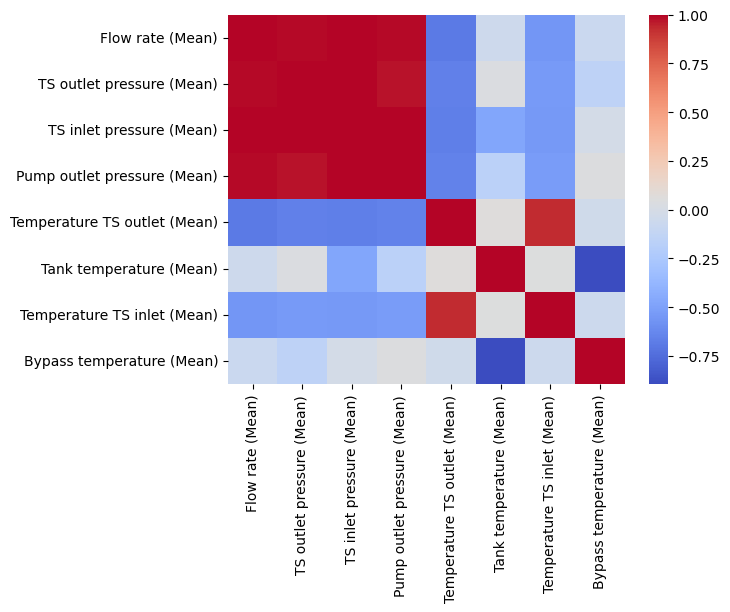

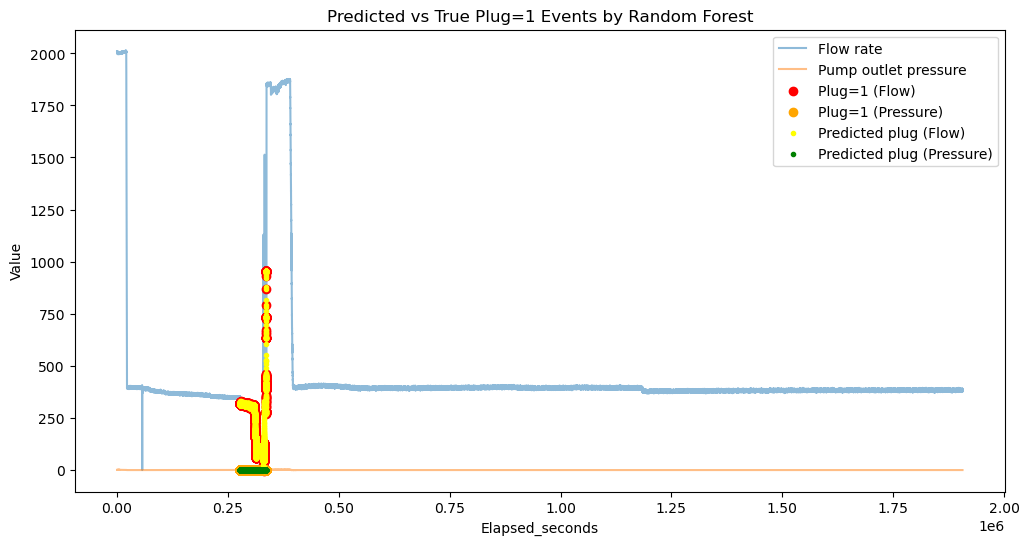

In [36]:
dataset1 = dp.load_data()
dataset2 = dp.load_data(path="../data/raw_data/data2/*.csv")
dataset5 = dp.load_data(path="../data/raw_data/data5/*.csv")
dataset6 = dp.load_data(path="../data/raw_data/data6/*.csv")
dataset8 = dp.load_data(path="../data/raw_data/data8/*.csv")

columns = dataset1.columns.tolist()
print("Columns to keep:", columns)

dataset2 = prepare(dataset2, columns, "2")
dataset5 = prepare(dataset5, columns, "5")
dataset6 = prepare(dataset6, columns, "6")
dataset8 = prepare(dataset8, columns, "8")

print(dataset5)

dp.create_target_column(dataset1)
dp.create_future_target(dataset1)


combined_data = pd.concat([dataset1, dataset5, dataset2], axis=0).reset_index(drop=True)

to_drop_from_X = ['Plug_future', 'Plug', 'Anomaly']

X, y = combined_data.drop(to_drop_from_X, axis=1), combined_data['Plug_future']

import seaborn as sns
sns.heatmap(X.corr(), cmap='coolwarm')  # or X.corr().abs() > 0.9


cutoff = int(0.8 * len(X))
train_X, train_y, test_X, test_y = X.iloc[:cutoff], y.iloc[:cutoff], X.iloc[cutoff:], y.iloc[cutoff:]

rf = rfc(n_estimators=100, max_depth=5, min_samples_leaf=20, class_weight='balanced')

datasetX = dataset1.drop(to_drop_from_X, axis=1)

rf.fit(train_X, train_y)
training_predictions = rf.predict(train_X)
predictions = rf.predict(test_X)

print("Training F1 Score:", f1_score(train_y, training_predictions))
print("Test F1 Score:", f1_score(test_y, predictions))


all_X = pd.concat([train_X, test_X], axis=0)
all_y = pd.concat([train_y, test_y], axis=0)

dv.visualize_predicted_vs_true(pd.concat([train_X, train_y], axis=1), training_predictions, model_name="Random Forest", anomalies=True, plotLabel=True)

DEBUG: df columns: Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)',
       'Plug_future'],
      dtype='object')


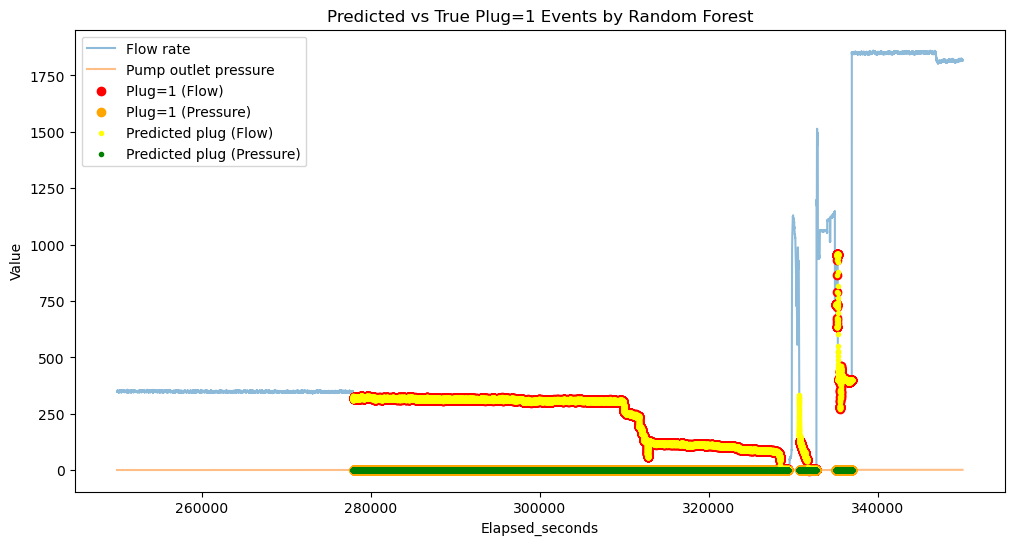

In [28]:
combined = pd.concat([train_X, train_y], axis=1)
dv.visualize_predicted_vs_true(combined.iloc[250000:350000], training_predictions[250000:350000], model_name="Random Forest", anomalies=True, plotLabel=True)

In [29]:
print(set(dataset5.columns) - set(dataset1.columns))

set()


In [30]:
print(datasetX.columns)

Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')


Dataset1 Predictions F1 Score: 0.996962708813769
DEBUG: df columns: Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)', 'Plug',
       'Anomaly', 'Plug_future'],
      dtype='object')


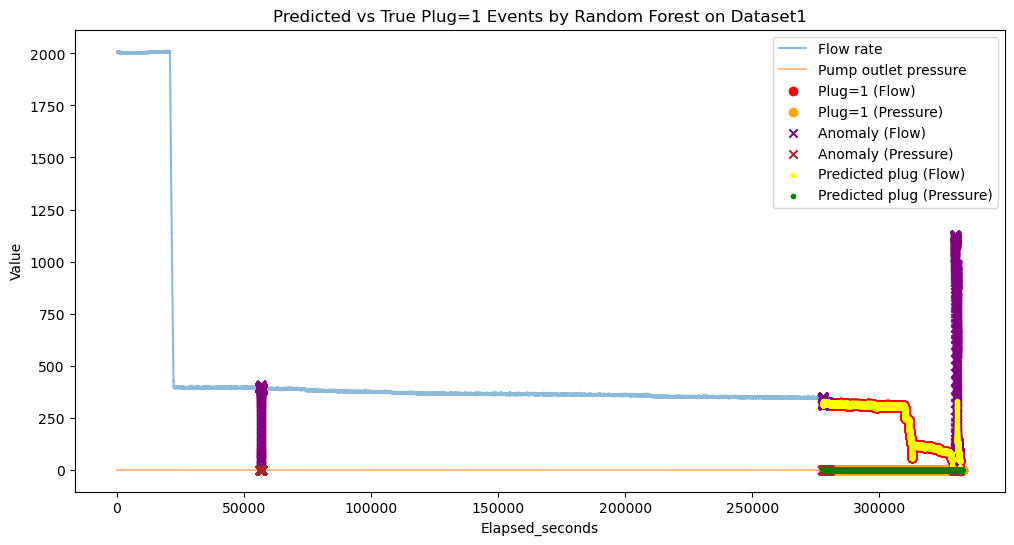

In [31]:
datasetX = datasetX[train_X.columns]
new_predictions = rf.predict(datasetX)
print("Dataset1 Predictions F1 Score:", f1_score(dataset1['Plug_future'], new_predictions))

dv.visualize_predicted_vs_true(dataset1, new_predictions, model_name="Random Forest on Dataset1", anomalies=True, plotLabel=True)



In [32]:
print(set(train_X.columns) - set(dataset6.columns))
print(set(train_X.columns) - set(dataset8.columns))

{'TS inlet pressure (Mean)'}
set()


dataset6 Predictions F1 Score: 0.4951219512195122
DEBUG: df columns: Index(['TS outlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Flow rate (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Temperature TS outlet (Mean)',
       'Bypass temperature (Mean)', 'Plug', 'Anomaly', 'Plug_future'],
      dtype='object')


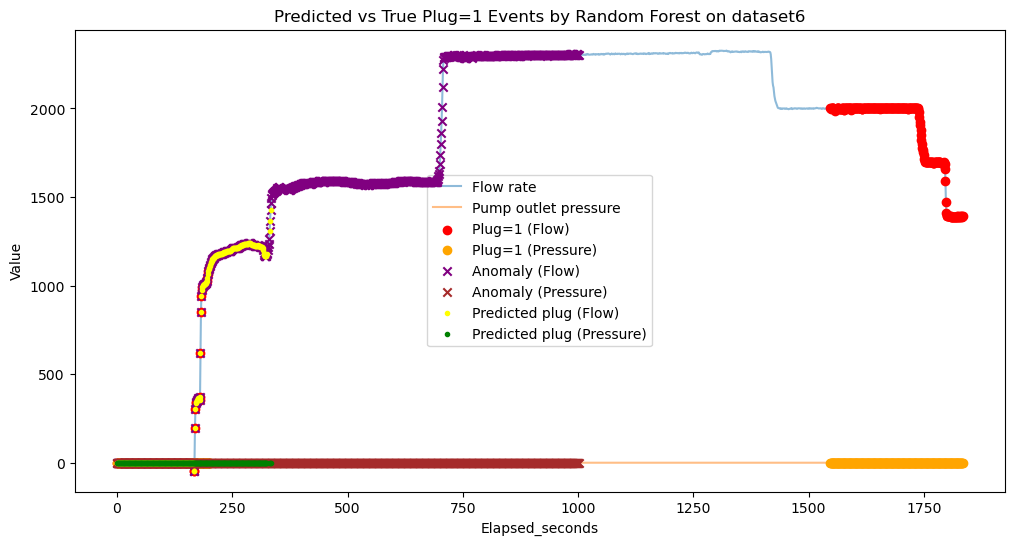

In [33]:
dataset6X = dataset6.drop(to_drop_from_X, axis=1)
if "TS inlet pressure (Mean)" not in dataset6X.columns:
    dataset6X["TS inlet pressure (Mean)"] = np.nan
data6 = dataset6X[train_X.columns] 

new_predictions = rf.predict(data6)
print("dataset6 Predictions F1 Score:", f1_score(dataset6['Plug_future'], new_predictions))

dv.visualize_predicted_vs_true(dataset6, new_predictions, model_name="Random Forest on dataset6", anomalies=True, plotLabel=True)

dataset8 Predictions F1 Score: 0.0
DEBUG: df columns: Index(['Temperature TS outlet (Mean)', 'Temperature TS inlet (Mean)',
       'Bypass temperature (Mean)', 'Tank temperature (Mean)',
       'TS outlet pressure (Mean)', 'TS inlet pressure (Mean)',
       'Pump outlet pressure (Mean)', 'Flow rate (Mean)', 'Plug', 'Anomaly',
       'Plug_future'],
      dtype='object')


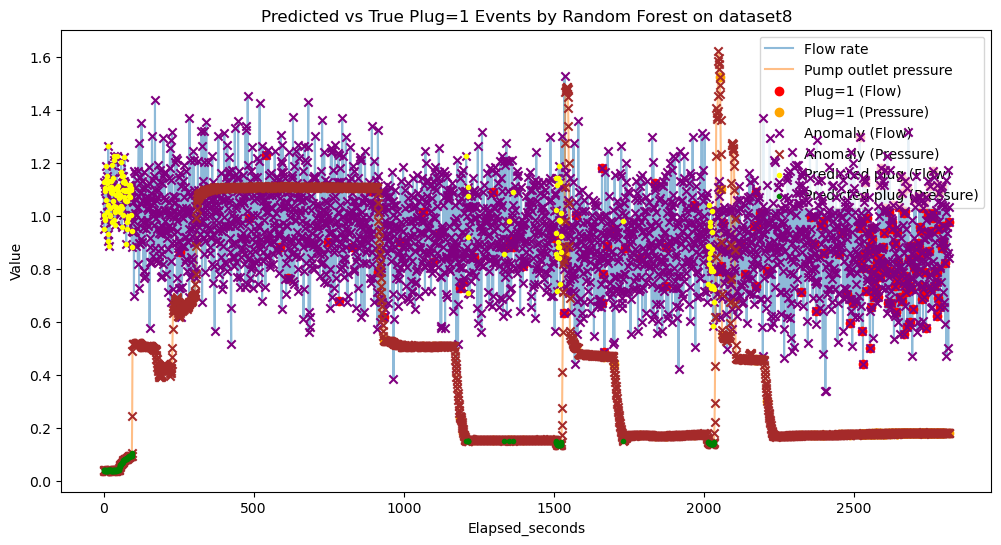

In [34]:
dataset8X = dataset8.drop(to_drop_from_X, axis=1)

data8 = dataset8X[train_X.columns]

new_predictions = rf.predict(data8)
print("dataset8 Predictions F1 Score:", f1_score(dataset8['Plug_future'], new_predictions))

dv.visualize_predicted_vs_true(dataset8, new_predictions, model_name="Random Forest on dataset8", anomalies=True, plotLabel=True)